# Investigate CSV Metrics


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
import yaml
from PIL import Image

IMG_EXTENSIONS = {".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp"}

In [5]:
path = Path("C:/Users/lababr/Desktop/fiber_unet_trainer_v2 - Sigurd/fiber_unet_trainer/predictions/metrics_with_sample_info.csv")
df = pd.read_csv(path)

#cols = df.columns.tolist()
#cols.insert(1, cols.pop())
#df = df[cols]

df.add
cols_to_drop = ["Activity","Simplyfied description of activity","Description of measurement place","Location","Sampling Notes","Sample","ID","Sampled time (hh:mm)","Start time of sampling (hh:mm)", "End time of sampling (hh:mm)", "Time decimal","End time of sampling (hh:mm)" ]
df.drop(columns = cols_to_drop, inplace = True)
df.insert(loc = 2, column = "Segmentation Quality", value = "NA")
df.insert(loc = 3, column = "Filter Loading", value = "NA")
df.insert(loc = 4, column = "Asbestos Present", value = False)
df.insert(loc = 5, column = "Asbestos Type", value = "NA")

outpath = f"{path.parent}\\{path.stem}_clean.csv"
df.to_csv(outpath, index=False)
df.head()

,image,split,Segmentation Quality,Filter Loading,Asbestos Present,Asbestos Type,accuracy,precision,recall,specificity,...,Median Otsu Coverage (%),GT Foreground Fraction (%),Frames Analyzed,Acquired Spectra,"Analyzed volume, cm3",Asbestos Counted,WHO Asbestos Counted,"Airborne WHO Asbestos Concentration, fibers/cm3",8 hr TWA,Sample Notes
0,a_E200175-12116-L_11.tif,train,NA,NA,False,NA,0.998681,0.641008,0.970771,0.998745,...,0.280206,0.230268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A33 - Site 2.tif,train,NA,NA,False,NA,0.997156,0.535925,0.843309,0.997651,...,1.809153,0.320666,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A97 - Site 3.tif,train,NA,NA,False,NA,0.996858,0.670774,0.952722,0.997129,...,11.242433,0.610282,10.0,152.0,312.519952,10.0,6.0,0.019199,0.0028,NaN
3,A78 - Site 3.tif,train,NA,NA,False,NA,0.995663,0.863128,0.996421,0.995642,...,3.981816,2.683744,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A44_15.00kV_0.10nA_16.9nm_500.00ns_067.tif,train,NA,NA,False,NA,0.998325,0.530386,0.907222,0.998496,...,0.501921,0.186942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
path = Path("C:/Users/lababr/Desktop/fiber_unet_trainer_v2 - Sigurd/fiber_unet_trainer/predictions/metrics_with_sample_info_clean.csv")
df = pd.read_csv(path)

num_cols = df.select_dtypes(include=np.number).columns

# --- summary table: mean, sd, sem per split ---
summary = df.groupby("split")[num_cols].agg(["mean", "std", "sem"])
# MultiIndex columns: (col, 'mean'), (col, 'std'), (col, 'sem')
summary.round(3)

tidy = (
    summary.stack(level=0)                      # bring the variable name into the index
           .rename_axis(index=["split", "variable"])
           .reset_index()
           .rename(columns={"std": "sd"})
)
# tidy columns: split | variable | mean | sd | sem
tidy.to_csv("split_summary.csv", index=False)   # optional export

accuracy               precision               recall                \
          mean    std    sem      mean    std    sem   mean    std    sem   
split                                                                       
test     0.992  0.014  0.002     0.584  0.240  0.036  0.719  0.219  0.033   
train    0.996  0.006  0.000     0.562  0.226  0.016  0.832  0.161  0.011   
val      0.995  0.005  0.001     0.552  0.245  0.036  0.751  0.219  0.033   

      specificity  ... WHO Asbestos Counted  \
             mean  ...                  sem   
split              ...                        
test        0.997  ...                5.124   
train       0.997  ...                1.998   
val         0.996  ...                4.258   

      Airborne WHO Asbestos Concentration, fibers/cm3               8 hr TWA  \
                                                 mean    std    sem     mean   
split                                                                          
test                                            0.096  0.107  0.023    0.033   
train                                           0.067  0.084  0.008    0.020   
val                                             0.066  0.082  0.015    0.024   

                    Sample Notes          
         std    sem         mean std sem  
split                                     
test   0.040  0.009          NaN NaN NaN  
train  0.033  0.003          NaN NaN NaN  
val    0.038  0.007          NaN NaN NaN  

[3 rows x 93 columns]

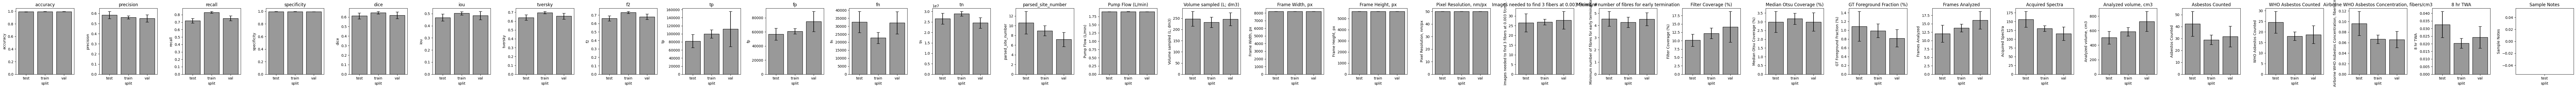

In [8]:
means = df.groupby("split")[num_cols].mean()
sems  = df.groupby("split")[num_cols].sem()

n = len(num_cols)
fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.5), squeeze=False)
for ax, col in zip(axes.flat, num_cols):
    ax.bar(means.index.astype(str), means[col], yerr=sems[col],
           capsize=4, color="0.6", edgecolor="black")
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.set_xlabel("split")
fig.tight_layout()
plt.show()

C:\Users\lababr\AppData\Local\Temp\ipykernel_3824\1878622193.py:4: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


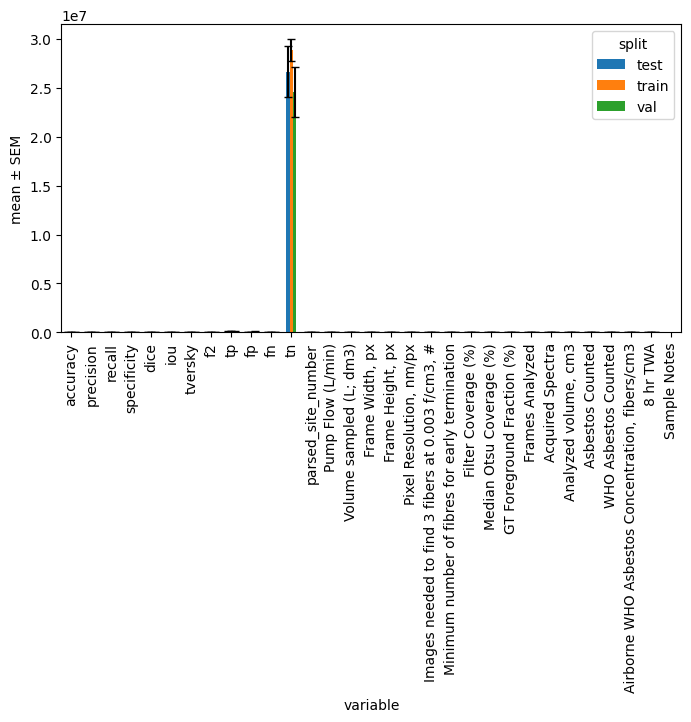

In [9]:
ax = means.T.plot(kind="bar", yerr=sems.T, capsize=3, figsize=(8, 4))
ax.set_ylabel("mean ± SEM")
ax.set_xlabel("variable")
plt.tight_layout(); plt.show()

# Split images/masks into train / validation / test folders

Reproduces the same pairing logic as `fiberseg.dataset.find_pairs` (glob `images_dir` for
`image_glob`, exclude `_mask` stems, match each image to its mask via `mask_pattern`), but
the train/val/test assignment for each image is looked up from the `split` column of
`predictions/metrics_with_sample_info_clean.csv` instead of being recomputed, so the
folders match that CSV exactly. Each image and its mask are then copied into a `train`,
`validation`, or `test` subfolder next to `images_dir`.

Edit `CONFIG_PATH` (or the manual overrides below it) to point at your data, then run all
cells.

In [1]:
import shutil
from pathlib import Path

import pandas as pd
import yaml

IMG_EXTENSIONS = {".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp"}

## Config

Loads `data.images_dir` / `data.masks_dir` / `data.image_glob` / `data.mask_pattern` from a
project YAML config. Set `CONFIG_PATH = None` to skip this and fill in the manual
overrides below instead.

`METRICS_CSV_PATH` points at the CSV holding the authoritative `image` -> `split` mapping.
`OUTPUT_DIR` defaults to a `split` folder next to `images_dir`
(`images_dir.parent / "split"`); override it below if you want the copies to land
somewhere else.

In [2]:
CONFIG_PATH = "../configs/simple_sweep.yaml"

# Manual overrides -- leave as None to use the value from CONFIG_PATH.
IMAGES_DIR = None
MASKS_DIR = None
IMAGE_GLOB = None
MASK_PATTERN = None
OUTPUT_DIR = None  # e.g. Path("../data_split")

METRICS_CSV_PATH = Path("../predictions/metrics_with_sample_info_clean.csv")

if CONFIG_PATH is not None:
    with open(CONFIG_PATH) as f:
        _data_cfg = yaml.safe_load(f)["data"]
else:
    _data_cfg = {}

images_dir = Path(IMAGES_DIR or _data_cfg["images_dir"])
masks_dir = Path(MASKS_DIR or _data_cfg["masks_dir"])
image_glob = IMAGE_GLOB or _data_cfg.get("image_glob", "*.tif")
mask_pattern = MASK_PATTERN or _data_cfg.get("mask_pattern", "{stem}_mask.tif")
output_dir = Path(OUTPUT_DIR) if OUTPUT_DIR is not None else images_dir.parent / "split"

print(f"images_dir:      {images_dir.resolve()}")
print(f"masks_dir:       {masks_dir.resolve()}")
print(f"image_glob:      {image_glob!r}")
print(f"mask_pattern:    {mask_pattern!r}")
print(f"metrics_csv:     {METRICS_CSV_PATH.resolve()}")
print(f"output_dir:      {output_dir.resolve()}")

images_dir:      C:\Users\lababr\Desktop\Current Training Material - fibers only - Preproc
masks_dir:       C:\Users\lababr\Desktop\Current Training Material - fibers only - Preproc
image_glob:      '*.tif'
mask_pattern:    '{stem}_mask.tif'
metrics_csv:     C:\Users\lababr\Desktop\fiber_unet_trainer_v2 - Sigurd\fiber_unet_trainer\predictions\metrics_with_sample_info_clean.csv
output_dir:      C:\Users\lababr\Desktop\split


## Pair images with masks and look up each one's split

Mirrors `fiberseg.dataset.find_pairs`'s glob/exclude/match logic to find each image's mask,
but instead of recomputing the split, looks it up by filename in the `image`/`split`
columns of `metrics_with_sample_info_clean.csv` so the folders match that CSV exactly.
`val` is renamed to `validation` for the output folder name. Images with no matching mask,
or no entry in the CSV, are skipped and reported below.

In [3]:
_metrics_df = pd.read_csv(METRICS_CSV_PATH, usecols=["image", "split"])
split_by_image = dict(zip(_metrics_df["image"], _metrics_df["split"]))
FOLDER_NAME_BY_SPLIT = {"train": "train", "val": "validation", "test": "test"}


def find_pairs_with_split(
    images_dir: Path,
    masks_dir: Path,
    image_glob: str,
    mask_pattern: str,
    split_by_image: dict,
) -> tuple[list[tuple[Path, Path, str]], list[str], list[str]]:
    image_paths = sorted(
        p for p in images_dir.glob(image_glob)
        if p.suffix.lower() in IMG_EXTENSIONS and not p.stem.endswith("_mask")
    )

    pairs = []
    no_mask = []
    no_split = []

    for img in image_paths:
        mask_name = mask_pattern.format(stem=img.stem, suffix=img.suffix, name=img.name)
        mask = masks_dir / mask_name
        if not mask.exists():
            no_mask.append(img.name)
            continue

        split = split_by_image.get(img.name)
        if split is None:
            no_split.append(img.name)
            continue

        pairs.append((img, mask, FOLDER_NAME_BY_SPLIT.get(split, split)))

    return pairs, no_mask, no_split


pairs, no_mask, no_split = find_pairs_with_split(images_dir, masks_dir, image_glob, mask_pattern, split_by_image)

counts = {"train": 0, "validation": 0, "test": 0}
for _, _, split in pairs:
    counts[split] = counts.get(split, 0) + 1

print(f"{len(pairs)} image/mask pairs found with a known split")
print(f"counts: {counts}")
if no_mask:
    print(f"{len(no_mask)} image(s) had no matching mask, skipped: {no_mask[:5]}{'...' if len(no_mask) > 5 else ''}")
if no_split:
    print(f"{len(no_split)} image(s) had no split in the CSV, skipped: {no_split[:5]}{'...' if len(no_split) > 5 else ''}")

298 image/mask pairs found with a known split
counts: {'train': 209, 'validation': 45, 'test': 44}
1 image(s) had no matching mask, skipped: ['A52_15.00kV_0.10nA_33.7nm_1.00µs_027.tif']


## Copy images and masks into train / validation / test folders

Copies each image and its mask, flat, into `output_dir/<split>/`
(e.g. `output_dir/train/sample01.tif` and `output_dir/train/sample01_mask.tif`).

In [4]:
for split in ("train", "validation", "test"):
    (output_dir / split).mkdir(parents=True, exist_ok=True)

for img_path, mask_path, split in pairs:
    dest_dir = output_dir / split
    shutil.copy2(img_path, dest_dir / img_path.name)
    shutil.copy2(mask_path, dest_dir / mask_path.name)

print(f"Copied {len(pairs)} image/mask pairs into {output_dir.resolve()}")

Copied 298 image/mask pairs into C:\Users\lababr\Desktop\split
